# Batch, dataset and data loarders

In [1]:
import json
import random

import numpy as np
import plotnine as pn
import requests
import torch
from torch import nn

from adl.sklearn import skl_regression
from adl import cooking, model_1p

pn.theme_set(pn.theme_minimal() + pn.theme(plot_background=pn.element_rect(fill="white")))

Jusqu'à présent, nous n'avons travaillé que sur de très petits ensembles de données factices, mais dans les
applications réelles du deep learning, les ensembles de données peuvent être énormes, soit
parce que nous avons un très grand nombre de points de données, soit parce que chaque
point de données est lui-même assez volumineux (comme les séquences, les images ou les vidéos). Dans
ce cas, il est impossible d'appliquer une étape d'apprentissage (passage en avant et
rétropropagation) à l'ensemble des données, en raison des limitations de mémoire.

Pour surmonter cette difficulté, les étapes d'apprentissage seront plutôt appliquées à des
*mini-batches* de données :

-   l'ensemble de données est divisé en sous-ensembles plus petits de points de données d'une
    taille donnée. Chaque sous-ensemble est appelé *mini-batch* ou *batch*.
-   l'étape d'apprentissage sera appliquée séquentiellement à chaque batch : le
    passage direct, la rétropropagation et l'ajustement des paramètres seront
    effectués pour chaque batch, l'un après l'autre.
-   une *epoch* est atteinte lorsque tous les batches ont été traités et que
    l'ensemble du jeu de données d'entraînement a été vu par le réseau.

Pour illustrer cela, nous réutiliserons l'exemple d'évaluation de recettes de gâteaux tiré du
cahier *overfitting*, où les évaluations étaient prédites en fonction du temps de cuisson.
 Mais cette fois-ci, nous générerons un jeu de données beaucoup plus important, comprenant 500 000
points de données.

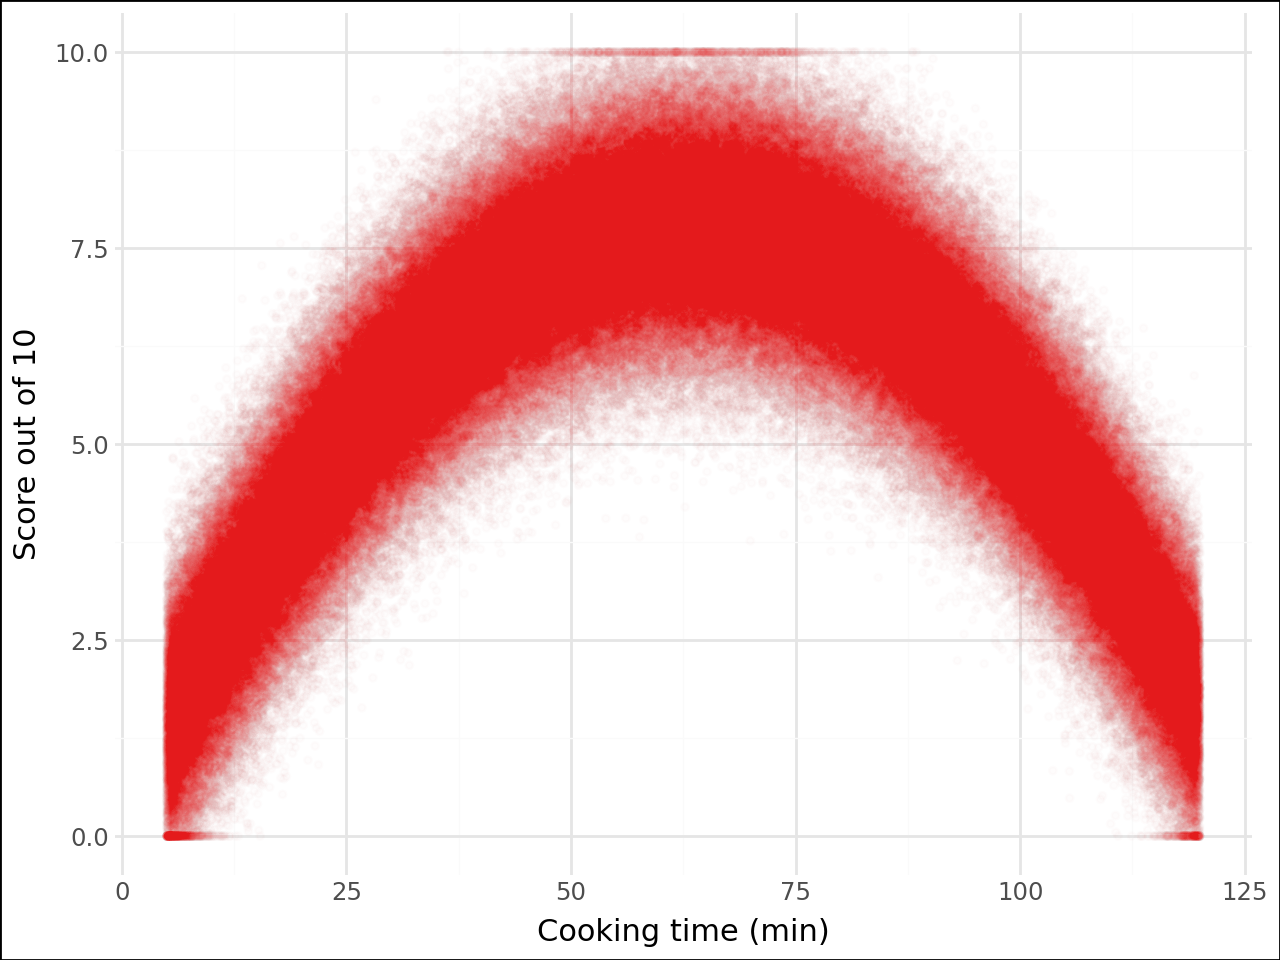

In [2]:
np.random.seed(1357)

time,score = cooking.generate_data(size = 500_000,noise_scale = 0.9)

cooking.scatter_plot(time,score,size=1,alpha=0.01)

On va definir une classe de réseau et un objet du modèle

In [3]:
class RegressionNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(in_features=1,out_features=10),
            nn.Sigmoid(),
            nn.Linear(in_features=10,out_features=1),
        )
    
    def forward(self,x):
        x=x -115 / 2
        return self.model(x)
    
model = RegressionNetwork()

L'entraînement sera identique à ce que nous avons fait précédemment.

In [4]:
def train_step(x,y,model,loss_fn,optimizer):
    model.train()

    optimizer.zero_grad()

    y_pred=model(x)

    loss=loss_fn(y_pred,y)

    loss.backward()

    optimizer.step()
    return loss

loss_fn = nn.MSELoss()
optimizer = torch.optim.AdamW(model.parameters(),lr=0.005)

La différence avec le tp précédent est dans la manière de lancer les étapes d'entraînement.

Avant, on appliquait une fois à tout le jeu de donnée a chaque epoch.

Maintenant, on introduit une deuxième boucle qui va itérer sur les lots du jeu de données. Les étapes d'entraînement est appliqué d'un lot à un autre. À la fin de chaque époch, nous calculons la perte moyenne par lot comme étant la perte globale de l'époch.

In [5]:
epochs = 10

batch_size = 10_000

n_batches = len(time) // batch_size

for epoch in range(epochs):
    loss=0
    for batch in range(n_batches):
        x_batch = time[batch * batch_size : (batch + 1) * batch_size -1]
        y_batch = score[batch * batch_size : (batch + 1) * batch_size -1]

        batch_loss = train_step(x_batch,y_batch,model,loss_fn,optimizer)

        loss += batch_loss.item()
    
    loss /= n_batches
    print(f"Epoch {epoch + 1:2} - loss: {loss:.4f}")

Epoch  1 - loss: 36.6678
Epoch  2 - loss: 26.4771
Epoch  3 - loss: 19.3667
Epoch  4 - loss: 14.5089
Epoch  5 - loss: 11.2185
Epoch  6 - loss: 8.9956
Epoch  7 - loss: 6.3835
Epoch  8 - loss: 5.3634
Epoch  9 - loss: 4.7656
Epoch 10 - loss: 4.4022


# Dataset and DataLoaders

Dans le précédent exemple, on réalisé l'extraction de batch manuellement, mais en pratique cela peut devenir plus compliqué. Pytorch fournit deux outils pour faire les batches plus simplement : *Dataset* et *DataLoader*.

- Un *Dataset* décrit la source de donnée, sa taille et la façon de récupérer une donnée. Il permet d'accéder aux données à partir d'un array numpy, d'un tensor , d'un fichier ou tout autre ressource accessible via le language Python.
- Un *Dataloader* est une objet qui permet de charger des données à partir d'un *Dataset* tout en gérant des fonctionnalités telles que le chargement par lots et le mélange aléatoire.

## Dataset

Pour présenter l'utilisation des *Dataset*, on va générer deux échantillon, un pour l'entraînement et un pour la validation:

In [6]:
time_train, score_train = cooking.generate_data(size=500_000, noise_scale=0.9)
time_valid, score_valid = cooking.generate_data(size=18_000, noise_scale=0.9)


L'étape suivante consiste à définir une classe `Dataset` pour nos données. Il s'agit d'une classe Python qui hérite de [torch.utils.data.Dataset](https://pytorch.org/docs/stable/data.html#torch.utils.data.Dataset)
et qui doit implémenter trois méthodes :

-   `__init__()`, le constructeur de classe
-   `__len__()`, qui doit renvoyer la longueur de notre ensemble de données (le nombre de points de données)
-   `__getitem__()`, qui, étant donné un indice entier comme argument, doit
    renvoyer une paire `(data, label)` correspondant à cet indice.

Nous allons ici créer une classe appelée `RegressionDataset` :

- le constructeur prend deux tenseurs `time` et `score` comme arguments
    et les stocke comme attributs. - la méthode `__len__()` renvoie la
    longueur de ces tenseurs.
- la méthode `__getitem__()` renvoie un tuple des valeurs de temps et de score
    à l'index donné.

In [7]:
from torch.utils.data import Dataset

class RegressionDataset(Dataset):
    def __init__(self,time,score):
        if len(time) != len(score):
            msg = "your in and out feature don't have the same length"
            raise ValueError(msg)
        self.time = time
        self.score = score
    
    def __len__(self):
        return len(self.score)
    
    def __getitem__(self,index):
        time_index = self.time[index]
        score_index = self.score[index]
        return time_index, score_index

Notre `Dataset` est assez simple ici, car il se contente de stocker et de récupérer des valeurs
à partir de tenseurs, mais il pourrait être plus complexe. Par exemple, le constructeur
pourrait obtenir une liste de noms de fichiers contenant des images et leurs étiquettes correspondantes,
 et la méthode `__getitem__` ouvrirait et lirait alors les fichiers
et prétraiterait les données d'image.

Maintenant que notre classe `RegressionDataset` est définie, nous pouvons créer deux
objets de jeu de données d'entraînement et de validation.

In [8]:
train_dataset = RegressionDataset(time_train, score_train)
valid_dataset = RegressionDataset(time_valid, score_valid)

Nous pouvons appliquer `len` à l'un de ces objets pour obtenir le nombre de ses points de données,
ou l'indexer pour obtenir un tuple (données, étiquette).

In [9]:
len(train_dataset)

500000

In [10]:
valid_dataset[1000]

(tensor([11.3892]), tensor([1.3240]))

## Chargeurs de données

Une fois nos objets `Dataset` définis, nous pouvons créer des objets
`Dataloader` associés, qui géreront l'extraction et le parcours des lots.
Pour cela, nous allons créer des instances
[torch.utils.data.DataLoader](https://pytorch.org/docs/stable/data.html#torch.utils.data.DataLoader) en leur passant (entre autres arguments possibles) :

- un objet `Dataset`
- la taille du lot
-   un argument `shuffle` : si `True`, les points de données seront remaniés
    de manière aléatoire avant chaque époque. Cela signifie que les lots seront différents d'une époque à l'autre.

Nous créons deux chargeurs d'entraînement et de validation avec une taille de lot de 10 000. Le chargeur d'entraînement est remanié, afin d'avoir des lots différents à chaque époque. Cela n'est pas utile pour le chargeur de validation.

In [11]:
from torch.utils.data import DataLoader

batch_size = 10_000

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=batch_size, shuffle=False)

Une fois créé, nous pouvons itérer sur un `Dataloader`. Chaque itération
renverra un lot de données `(temps, score)`.

Par exemple, nous pouvons itérer sur notre chargeur de validation. Cela donne deux lots, le premier avec la taille souhaitée de 10 000, et le second
avec une taille de 8 000 (car notre ensemble de données de validation ne contient que 18 000 points).

In [12]:
for batch in valid_loader:
    time, score = batch
    print(time.shape, score.shape)

torch.Size([10000, 1]) torch.Size([10000, 1])
torch.Size([8000, 1]) torch.Size([8000, 1])


Si nous itérons à nouveau, nous commencerons une nouvelle époque et obtiendrons à nouveau les mêmes lots.

In [13]:
for batch in valid_loader:
    time, score = batch
    print(time.shape, score.shape)

torch.Size([10000, 1]) torch.Size([10000, 1])
torch.Size([8000, 1]) torch.Size([8000, 1])


Nous pouvons réécrire notre code d'entraînement à l'aide de nos chargeurs de données. À l'intérieur de chaque époque, nous parcourons d'abord notre objet `train_loader` et exécutons une étape d'entraînement sur le lot obtenu. Ensuite, une fois que tous les lots d'entraînement ont été traités, nous parcourons notre `valid_loader`, cette fois-ci pour calculer la perte de validation pour cette époque.

In [14]:
model = RegressionNetwork()

loss_fn = nn.MSELoss()
optimizer = torch.optim.AdamW(model.parameters(),lr=0.005)

epochs = 5

for epoch in range(epochs):
    loss = 0

    # Iterate through training batches
    for x_batch, y_batch in train_loader:
        # Set model in train mode
        model.train()
        # Run a training step and accumulate loss value
        batch_loss = train_step(x_batch, y_batch, model, loss_fn, optimizer)
        loss += batch_loss.item()

    # Compute average training loss for this epoch
    loss /= len(train_loader)

    # Iterate through validation batches
    valid_loss = 0
    
    for x_valid_batch, y_valid_batch in valid_loader:
        # Set model in evaluation (inference) mode
        model.eval()
        # Compute and accumulate the batch loss
        y_valid_pred = model(x_valid_batch)
        valid_batch_loss = loss_fn(y_valid_pred, y_valid_batch)
        valid_loss += valid_batch_loss

    # Compute the average validation loss for this epoch
    valid_loss /= len(valid_loader)

    print(f"{epoch + 1:5}. loss: {loss:5.3f}, valid_loss: {valid_loss:5.3f}")


    1. loss: 23.434, valid_loss: 16.516
    2. loss: 12.343, valid_loss: 8.501
    3. loss: 6.560, valid_loss: 4.892
    4. loss: 3.947, valid_loss: 3.030
    5. loss: 2.774, valid_loss: 2.559


L'entraînement fonctionne bien, même si elle est plus lente qu'auparavant. Cependant, le ralentissement serait moindre si le coût de l'opération `__getitem__()` était plus élevé (si, par exemple, nous lisions un fichier). Et nous disposons de quelques fonctionnalités supplémentaires intéressantes, telles que la gestion automatique de la taille du dernier lot ou le mélange des données d'entraînement entre chaque époque.

**Exercice**

La fonction Python suivante utilise l'API [Open meteo
](https://open-meteo.com/en/docs) pour obtenir différentes informations météorologiques quotidiennes pour les 30 derniers jours au LBBE.

In [15]:
def get_weather_data():
    url = "https://api.open-meteo.com/v1/forecast?latitude=45.78&longitude=4.87&daily=precipitation_sum,temperature_2m_mean,wind_speed_10m_mean&past_days=30"
    data = requests.get(url).json()["daily"]  # noqa: S113
    return data

Les données renvoyées sont un dictionnaire Python contenant les champs suivants :

-   `wind_speed_1Om_mean` : vitesse moyenne quotidienne du vent
-   `temperature_2m_mean` : température moyenne quotidienne
-   `precipitation_sum` : précipitations quotidiennes totales

1.  Utilisez la fonction `get_weather_data` pour créer un nouvel objet `data`
2.  Créez une classe `WeatherDataset` qui convertit la vitesse du vent, la température et les précipitations en tenseurs et les stocke en tant qu'attributs, puis renvoie la température et la vitesse du vent en tant que données d'entrée, et les précipitations en tant que cible.
3.  Créez un objet `weather_dataset` à partir de votre classe `WeatherDataset`
4.  Créez un objet `DataLoader` pour `weather_dataset` avec une
    `batch_size` de 10 et sans shuffle
5.  Itérez sur le chargeur de données et imprimez les valeurs du lot

In [16]:
data = get_weather_data()
print(data.keys())


dict_keys(['time', 'precipitation_sum', 'temperature_2m_mean', 'wind_speed_10m_mean'])


In [17]:
from torch.utils.data import Dataset

class WeatherDataset(Dataset):
    def __init__(self,data):
        self.wind_speed = torch.tensor(data["wind_speed_10m_mean"])
        self.temperature = torch.tensor(data["temperature_2m_mean"])
        self.precipitations = torch.tensor(data["precipitation_sum"])
    
    def __len__(self):
        return len(self.precipitations)

    def __getitem__(self,index):
        input = torch.tensor([self.wind_speed[index], self.temperature[index]])
        target = self.precipitations[index]
        return input, target

weather_dataset = WeatherDataset(data)


In [18]:
weather_loader = DataLoader(weather_dataset, batch_size=10, shuffle=False)
for input, data in weather_loader:
    print(input,data)

tensor([[ 2.9000, 13.4000],
        [ 4.4000, 13.2000],
        [ 6.9000, 13.9000],
        [13.0000, 14.6000],
        [ 5.3000, 12.2000],
        [ 2.1000, 13.8000],
        [ 7.6000, 15.7000],
        [ 5.8000, 12.3000],
        [ 6.7000, 12.2000],
        [ 4.2000, 13.3000]]) tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.1000, 0.0000,
        0.0000])
tensor([[ 4.2000, 13.5000],
        [ 9.2000, 14.7000],
        [ 7.1000, 14.7000],
        [ 5.5000, 13.2000],
        [ 3.9000, 12.3000],
        [ 4.3000, 12.9000],
        [ 3.5000, 12.2000],
        [ 5.4000, 13.1000],
        [ 3.4000, 11.6000],
        [ 5.4000, 11.9000]]) tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])
tensor([[ 2.9000, 13.1000],
        [12.1000, 14.3000],
        [12.6000, 16.5000],
        [11.6000, 15.3000],
        [15.3000, 17.4000],
        [16.1000, 15.8000],
        [ 6.1000, 11.6000],
        [ 5.5000, 12.1000],
        [ 6.0000, 10.4000],
        [ 5.2000,  9.9000]]) tensor([ 0.

# Effect de la taille de batch sur l'entraînement

Outre le fait de permettre l'entraînement d'un modèle à partir d'ensembles de données plus importants, l'utilisation de mini-lots a également un effet sur le processus d'entraînement lui-même. Cela s'explique
par le fait que lors de l'utilisation de lots, la fonction de perte sera légèrement différente à chaque étape d'entraînement (et donc les gradients et les ajustements des paramètres seront également légèrement différents).

Pour illustrer ce point, nous réutilisons un exemple précédent de régression linéaire avec un seul paramètre $w$ (la pente de la ligne). Nous générons d'abord un ensemble de données aléatoire de 500 points de valeurs `x` et `y` où `y` est égal à `x * 2` plus un certain bruit.

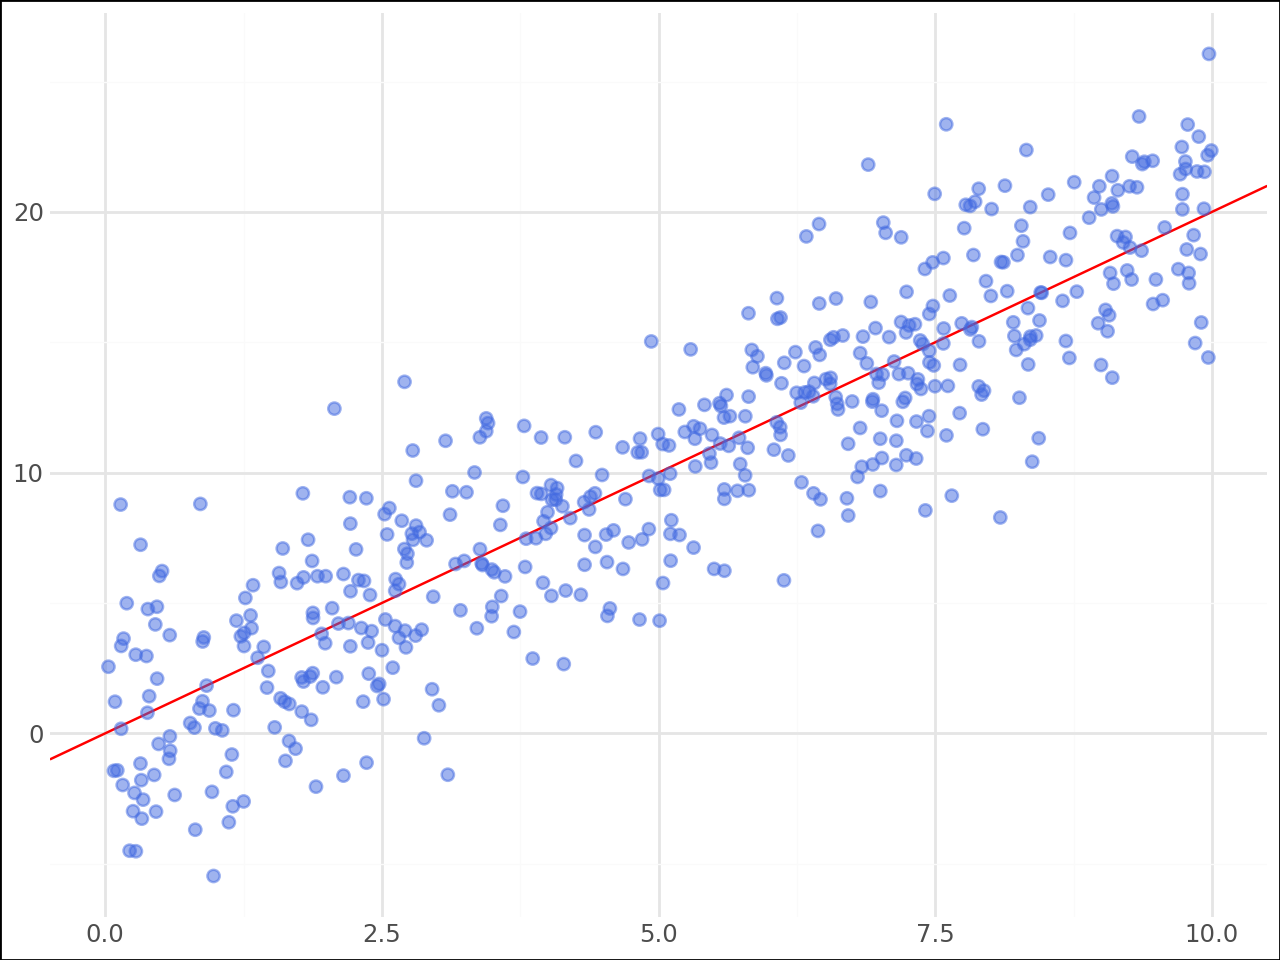

In [19]:
n_points = 500
np.random.seed(1337)
# Generate x and y values
x = np.random.uniform(low=0, high=10, size=n_points)
y = x * 2 + np.random.normal(loc=0, scale=3, size=n_points)

# Convert to tensors
xt = torch.tensor(x).view(-1, 1)
yt = torch.tensor(y).view(-1, 1)

# Plot the dataset
(
    pn.ggplot(mapping=pn.aes(x=x, y=y))
    + pn.geom_abline(slope=2, intercept=0, color="red")
    + pn.geom_point(color="royalblue", size=2, alpha=0.5)
    + pn.coord_cartesian(xlim=(0, 10))
)

Nous pouvons tracer la fonction de perte pour l'ensemble de notre jeu de données, *c'est-à-dire* l'erreur quadratique moyenne
de notre modèle $y = w \times x$ pour différentes valeurs de $w$.

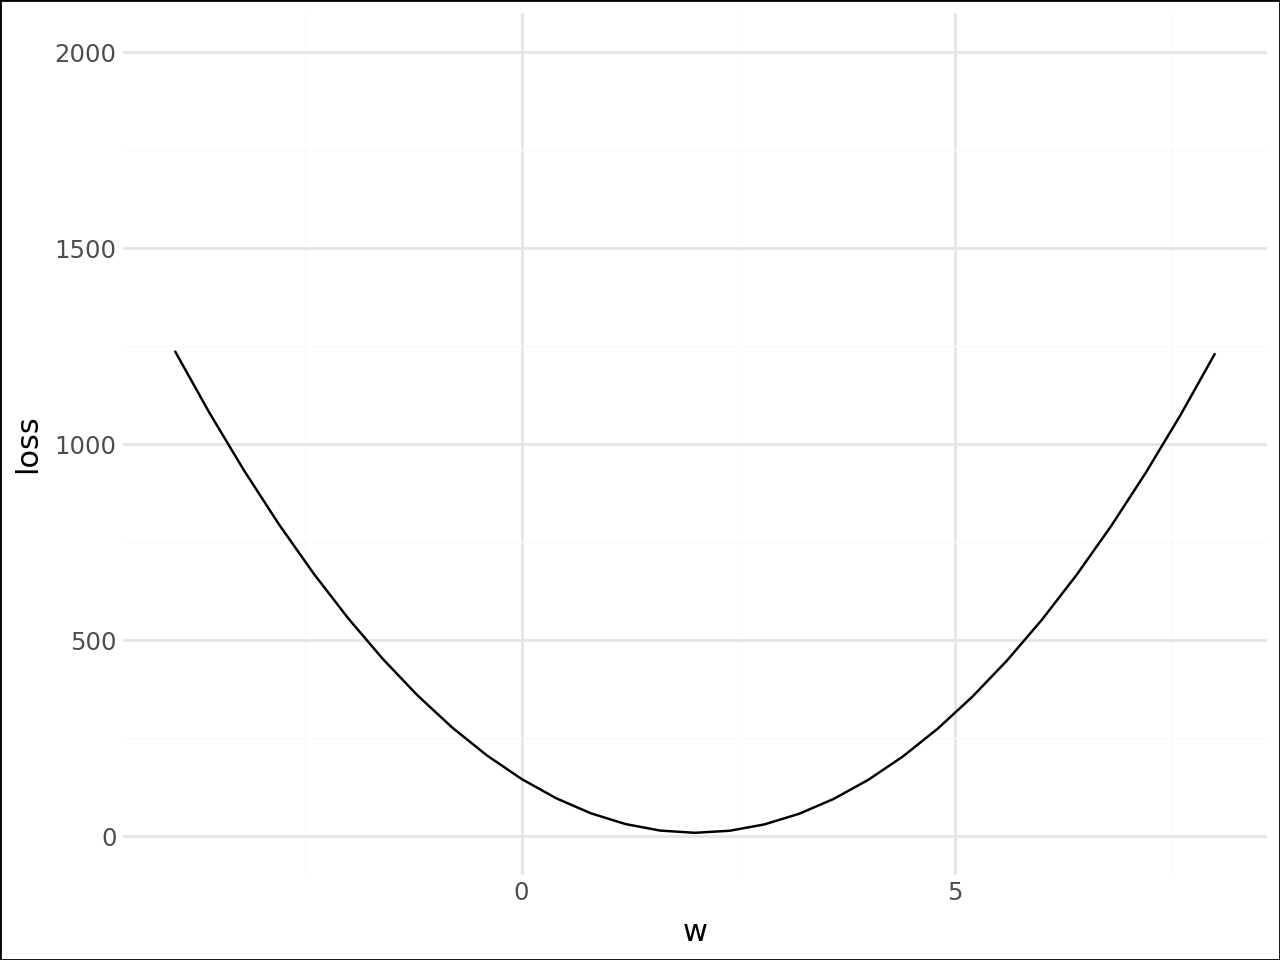

In [20]:
model_1p.plot_loss(xt, yt, wmin=-4, wmax=8, gradient=False, ylim=(0, 2000))

Nous pouvons voir que si $w = 0$ (*c'est-à-dire* avec une ligne de régression horizontale),
la valeur de perte sur notre ensemble de données est d'environ 200. Comme prévu, la valeur minimale
de perte est atteinte pour $w$ approximativement égal à 2.

Mais que se passe-t-il si nous calculons cette fonction de perte non pas sur l'ensemble des
données, mais seulement sur un sous-ensemble de celles-ci, par exemple 32 points de données ?

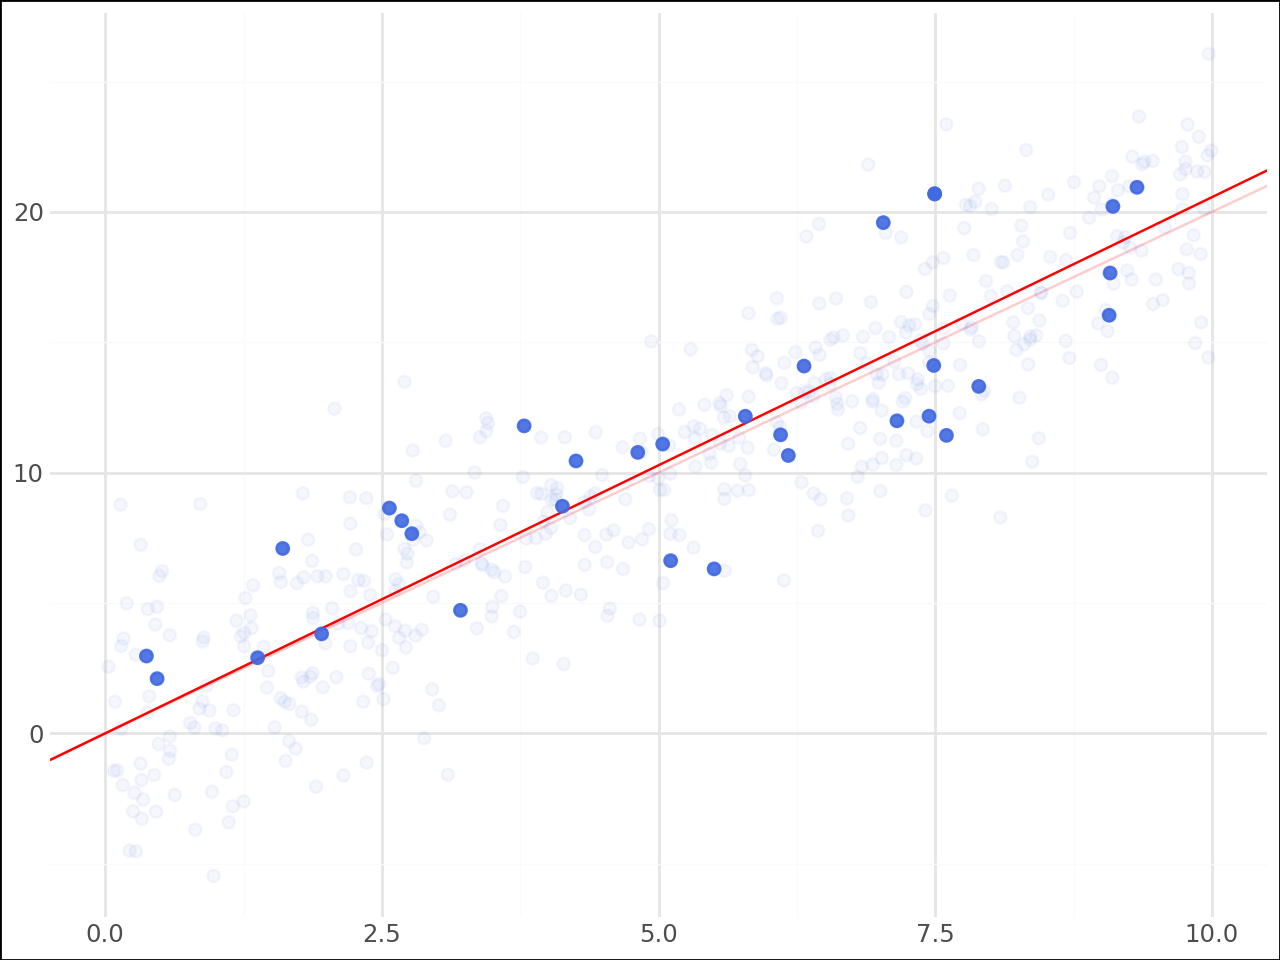

In [21]:
indices = random.choices(range(len(x)), k=32)
x_subset, y_subset = x[indices], y[indices]
reg = skl_regression(x_subset, y_subset, fit_intercept=False)

# Plot the dataset
(
    pn.ggplot()
    + pn.geom_abline(slope=2, intercept=0, color="red", alpha=0.2)
    + pn.geom_point(mapping=pn.aes(x=x, y=y), color="royalblue", size=2, alpha=0.05)
    + pn.geom_abline(slope=reg["slope"], intercept=0, color="red")
    + pn.geom_point(mapping=pn.aes(x=x_subset, y=y_subset), color="royalblue", size=2, alpha=0.9)
    + pn.coord_cartesian(xlim=(0, 10))
)

Si nous prenons un sous-ensemble de nos données, nous pouvons voir que la pente de la
ligne de régression est légèrement différente. Nous pouvons donc supposer que les
valeurs globales de la fonction de perte seront également différentes.

Nous pouvons visualiser cela en échantillonnant aléatoirement 32 points de données, en traçant la
fonction de perte associée (en gris sur le graphique ci-dessous) et en la comparant avec la
fonction de perte de l'ensemble de nos données (la ligne rouge en pointillés).

In [23]:
model_1p.plot_batch_loss(xt, yt, batch_size=32, n_batches=1)

ValueError: '#F40FF' is not a valid value for color: supported inputs are (r, g, b) and (r, g, b, a) 0-1 float tuples; '#rrggbb', '#rrggbbaa', '#rgb', '#rgba' strings; named color strings; string reprs of 0-1 floats for grayscale values; 'C0', 'C1', ... strings for colors of the color cycle; and pairs combining one of the above with an alpha value